YENİ VERİ KEŞFİ VE BAZİ  İSTATİSTİKSEL ANALİZLER

 EN VOLATİL(RİSKLİ) 10 HİSSE
Hisse  Volatilite_Std_Sapma
 CSCO              3.949663
  HPQ              3.902874
   AA              3.588814
 INTC              3.293361
  CAT              3.259750
  BAC              3.218526
  DIS              2.865833
   DD              2.738341
  XOM              2.683961
  AXP              2.678678

EN AZ VOLATİL(RİSKSİZ)10 HİSSE 
Hisse  Volatilite_Std_Sapma
  WMT              1.520859
   PG              1.635191
   VZ              1.672929
  IBM              1.702110
   KO              1.761433
  MCD              1.782776
    T              1.838608
 KRFT              1.855200
 MSFT              1.906652
  MMM              1.987827

TOPLAM İŞLEM HACMİ EN YÜKSEK OLAN 10 HİSSE 
stock      volume
  BAC 18074978389
 CSCO  8966539693
 INTC  7475560415
 MSFT  7242469806
   GE  6598451959
  PFE  5686674015
  JPM  3777725413
    T  3307182832
   AA  3240970255
  HPQ  2371460755


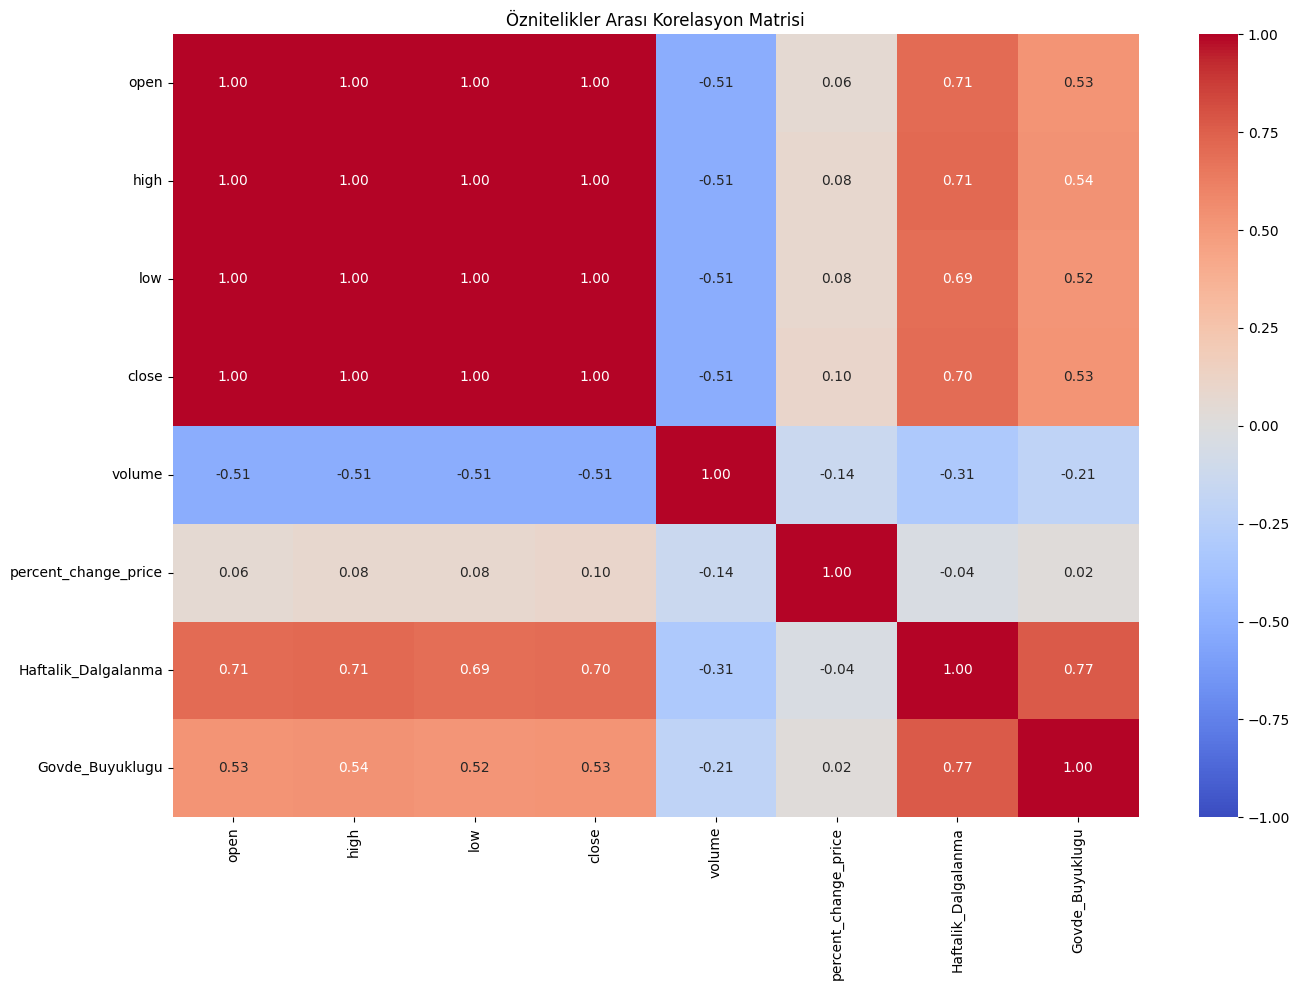

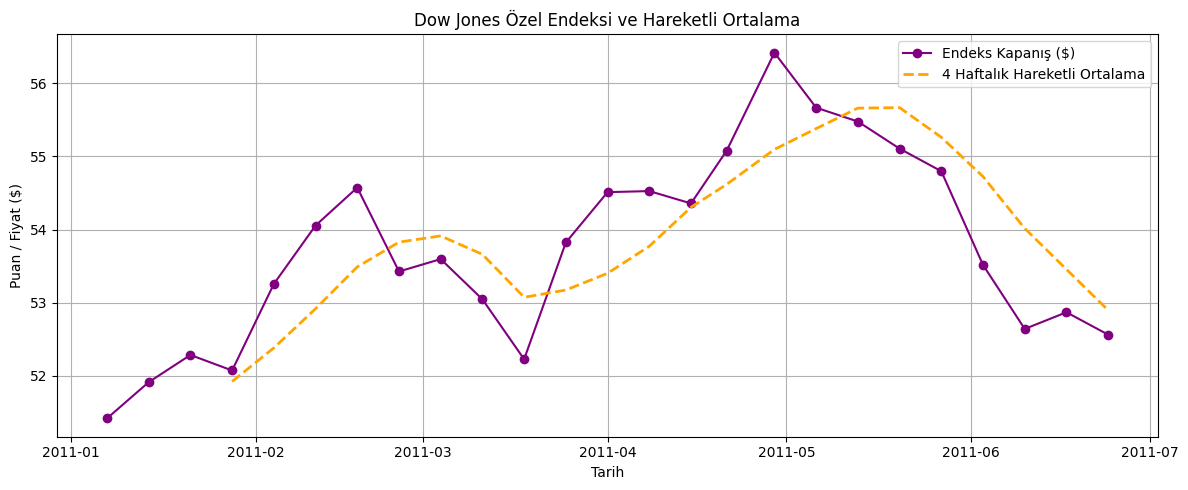

ALGORİTMALI PİYASA ENDEKSİ YÖN TAHMİNİ SONUÇLARI
                     Algoritma  Doğruluk Oranı (%)
     Basit Bayes (Naive Bayes)                80.0
              Lineer Regresyon                80.0
            Lojistik Regresyon                80.0
                Rastgele Orman                60.0
Destek Vektör Makineleri (SVM)                60.0
      Yapay Sinir Ağları (YSA)                60.0
                           CNN                40.0
                   Karar Ağacı                40.0
        K-En Yakın Komşu (KNN)                40.0


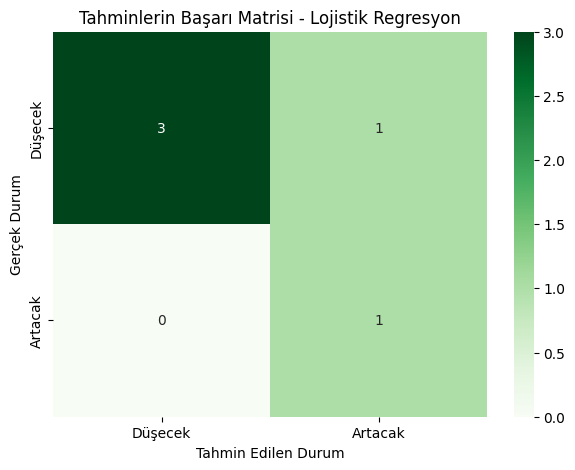

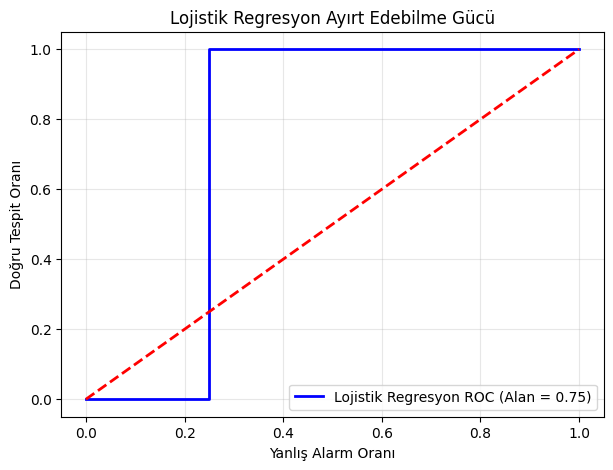

30 HİSSE İÇİN GELECEK HAFTA YÖN TAHMİNLERİ:LİNEER-LOJİSTİK REGRESYON
Hisse Sembolü  Lineer Tahmin Lojistik Tahmin Kıyaslama
           AA Yükselecek (▲)  Yükselecek (▲)      AYNI
          AXP    Düşecek (▼)     Düşecek (▼)      AYNI
           BA Yükselecek (▲)  Yükselecek (▲)      AYNI
          BAC    Düşecek (▼)     Düşecek (▼)      AYNI
          CAT Yükselecek (▲)  Yükselecek (▲)      AYNI
         CSCO    Düşecek (▼)     Düşecek (▼)      AYNI
          CVX Yükselecek (▲)  Yükselecek (▲)      AYNI
           DD Yükselecek (▲)  Yükselecek (▲)      AYNI
          DIS    Düşecek (▼)  Yükselecek (▲) FARKLI ⚠️
           GE Yükselecek (▲)  Yükselecek (▲)      AYNI
           HD Yükselecek (▲)  Yükselecek (▲)      AYNI
          HPQ    Düşecek (▼)     Düşecek (▼)      AYNI
          IBM Yükselecek (▲)  Yükselecek (▲)      AYNI
         INTC Yükselecek (▲)  Yükselecek (▲)      AYNI
          JNJ Yükselecek (▲)     Düşecek (▼) FARKLI ⚠️
          JPM    Düşecek (▼)     Düşecek (▼)      A

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten #
import warnings
warnings.filterwarnings('ignore')

#veri setini okuyup df ismideki tabloya kaydediyoruz
df = pd.read_csv('dow_jones_index.data')

cols_to_clean = ['open', 'high', 'low', 'close', 'next_weeks_open', 'next_weeks_close']

for col in cols_to_clean:
    # veriyi stringe çevirip $ işaretini kaldıroruz , veriyi float tiğine dönüştürüyoruz
    df[col] = df[col].astype(str).str.replace('$', '').astype(float)

df['date'] = pd.to_datetime(df['date'])

# hisseleri isimlerine ve tarihlerine göre göre eskiden yeniye srıalıyoruz
df = df.sort_values(by=['stock', 'date'])

# tabloda olamyan veriler varsa boşluklara sütün ortalamalarını ekliyoruz,sistemin çökmemesi için gerekli
df = df.fillna(df.mean(numeric_only=True))

# piyasa hareketlerini anlamlandırmak için haftalık en yüksek ve en düşük fiyatın farkını alarak yeni özellik sütunu oluşturduk
df['Haftalik_Dalgalanma'] = df['high'] - df['low']

# grafikteki gövdeyi bulmak için açılış-kapanış fiyatları arasındaki farkın mutlak değerini aldık
df['Govde_Buyuklugu'] = abs(df['close'] - df['open'])

# O hafta hem hissenin fiyatı hem hacmi artmışsa bu güçlü bir sinyal(yani 1) olarak kaydediliyor, değilse 0 yazıyoruz
df['Fiyat_Hacim_Trendi'] = ((df['percent_change_price'] > 0) &
                            (df['percent_change_volume_over_last_wk'] > 0)).astype(int)


print("YENİ VERİ KEŞFİ VE BAZİ  İSTATİSTİKSEL ANALİZLER")
volatilite_df = df.groupby('stock')['percent_change_price'].std().reset_index()
volatilite_df.columns = ['Hisse', 'Volatilite_Std_Sapma']
en_volatil_10 = volatilite_df.nlargest(10, 'Volatilite_Std_Sapma')
en_az_volatil_10 = volatilite_df.nsmallest(10, 'Volatilite_Std_Sapma')

print("\n EN VOLATİL(RİSKLİ) 10 HİSSE")
print(en_volatil_10.to_string(index=False))

print("\nEN AZ VOLATİL(RİSKSİZ)10 HİSSE ")
print(en_az_volatil_10.to_string(index=False))

hacim_df = df.groupby('stock')['volume'].sum().reset_index()
en_cok_hacim_10 = hacim_df.nlargest(10, 'volume')

print("\nTOPLAM İŞLEM HACMİ EN YÜKSEK OLAN 10 HİSSE ")
print(en_cok_hacim_10.to_string(index=False))

# korelasyon matrisi çizim
plt.figure(figsize=(14, 10))
sayisal_sutunlar = ['open', 'high', 'low', 'close', 'volume', 'percent_change_price',
                    'Haftalik_Dalgalanma', 'Govde_Buyuklugu']
sns.heatmap(df[sayisal_sutunlar].corr(), cmap='coolwarm', annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('Öznitelikler Arası Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('oznitelik_korelasyonu.png')
plt.show()
#piyasa trendi için grafik
market_df = df.groupby('date').agg({
    'close': 'mean',
    'volume': 'sum',
    'Haftalik_Dalgalanma': 'mean',
    'Govde_Buyuklugu': 'mean'
}).reset_index()

market_df['Hareketli_Ortalama_4Hafta'] = market_df['close'].rolling(window=4).mean()

# endeks grafiği
plt.figure(figsize=(12, 5))
plt.plot(market_df['date'], market_df['close'], marker='o', linestyle='-', color='purple', label='Endeks Kapanış ($)')
plt.plot(market_df['date'], market_df['Hareketli_Ortalama_4Hafta'], linestyle='--', color='orange', linewidth=2, label='4 Haftalık Hareketli Ortalama')
plt.title('Dow Jones Özel Endeksi ve Hareketli Ortalama')
plt.xlabel('Tarih')
plt.ylabel('Puan / Fiyat ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('endeks_ve_hareketli_ortalama.png')
plt.show()

#özel endeks üzerinden modelleri doğruluk oranları
market_df['Gelecek_Hafta_Kapanis'] = market_df['close'].shift(-1)
market_df['Piyasa_Artacak_Mi'] = (market_df['Gelecek_Hafta_Kapanis'] > market_df['close']).astype(int)
market_df_clean = market_df.dropna()

features_market = ['close', 'volume', 'Haftalik_Dalgalanma', 'Govde_Buyuklugu']
X_m = market_df_clean[features_market].values
y_m = market_df_clean['Piyasa_Artacak_Mi'].values

split_idx = int(len(market_df_clean) * 0.8)
X_train, X_test = X_m[:split_idx], X_m[split_idx:]
y_train, y_test = y_m[:split_idx], y_m[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}
models = {
    'Rastgele Orman': RandomForestClassifier(random_state=42),
    'Karar Ağacı': DecisionTreeClassifier(random_state=42),
    'K-En Yakın Komşu (KNN)': KNeighborsClassifier(),
    'Basit Bayes (Naive Bayes)': GaussianNB(),
    'Destek Vektör Makineleri (SVM)': SVC(probability=True, random_state=42),
    'Yapay Sinir Ağları (YSA)': MLPClassifier(random_state=42, max_iter=1000),
    'Lojistik Regresyon': LogisticRegression(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    results[name] = accuracy_score(y_test, model.predict(X_test_scaled))

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results['Lineer Regresyon'] = accuracy_score(y_test, (lr.predict(X_test_scaled) > 0.5).astype(int))

tf.random.set_seed(42)
try:
    cnn = Sequential([
        Conv1D(filters=16, kernel_size=2, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
        Flatten(),
        Dense(10, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    cnn.fit(X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1), y_train, epochs=30, verbose=0)
    _, acc = cnn.evaluate(X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1), y_test, verbose=0)
    results['CNN'] = acc
except: pass

res_df = pd.DataFrame(list(results.items()), columns=['Algoritma', 'Doğruluk Oranı (%)']).sort_values(by='Doğruluk Oranı (%)', ascending=False)
res_df['Doğruluk Oranı (%)'] = (res_df['Doğruluk Oranı (%)'] * 100).round(2)

print("ALGORİTMALI PİYASA ENDEKSİ YÖN TAHMİNİ SONUÇLARI")
print(res_df.to_string(index=False))

# grafikleri en yüksek doğruluğu veren Lojistik Regresyon ile çiziyoruz
viz_model = LogisticRegression(random_state=42)
viz_model.fit(X_train_scaled, y_train)
y_pred = viz_model.predict(X_test_scaled)
y_probs = viz_model.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Düşecek', 'Artacak'], yticklabels=['Düşecek', 'Artacak'])
plt.title('Tahminlerin Başarı Matrisi - Lojistik Regresyon')
plt.ylabel('Gerçek Durum')
plt.xlabel('Tahmin Edilen Durum')
plt.savefig('confusion_matrix_lojistik.png')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Lojistik Regresyon ROC (Alan = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('Yanlış Alarm Oranı')
plt.ylabel('Doğru Tespit Oranı')
plt.title('Lojistik Regresyon Ayırt Edebilme Gücü')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_egrisi_lojistik.png')
plt.show()

print("30 HİSSE İÇİN GELECEK HAFTA YÖN TAHMİNLERİ:LİNEER-LOJİSTİK REGRESYON")

df['Hedef_Artacak_Mi'] = (df['next_weeks_close'] > df['close']).astype(int)
features_stock = ['open', 'high', 'low', 'close', 'volume', 'Haftalik_Dalgalanma', 'Govde_Buyuklugu']
tahmin_sonuclari = []

for hisse in df['stock'].unique():
    hisse_df = df[df['stock'] == hisse].copy()
    train_data = hisse_df.iloc[:-1]
    test_data = hisse_df.iloc[-1:]
    if len(train_data) < 2: continue

    X_train_stk = train_data[features_stock].values
    y_train_stk = train_data['Hedef_Artacak_Mi'].values
    X_test_stk = test_data[features_stock].values

    scaler_stk = StandardScaler()
    X_train_scaled_stk = scaler_stk.fit_transform(X_train_stk)
    X_test_scaled_stk = scaler_stk.transform(X_test_stk)

    lin_model = LinearRegression()
    lin_model.fit(X_train_scaled_stk, y_train_stk)
    lin_pred = 1 if lin_model.predict(X_test_scaled_stk)[0] > 0.5 else 0

    log_model = LogisticRegression(random_state=42)
    log_model.fit(X_train_scaled_stk, y_train_stk)
    log_pred = log_model.predict(X_test_scaled_stk)[0]

    tahmin_sonuclari.append({
        'Hisse Sembolü': hisse,
        'Lineer Tahmin': 'Yükselecek (▲)' if lin_pred == 1 else 'Düşecek (▼)',
        'Lojistik Tahmin': 'Yükselecek (▲)' if log_pred == 1 else 'Düşecek (▼)',
        'Kıyaslama': 'AYNI' if lin_pred == log_pred else 'FARKLI ⚠️'
    })

tahmin_df = pd.DataFrame(tahmin_sonuclari)
print(tahmin_df.to_string(index=False))
